In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json


In [ ]:
def combine_subjects(df, codes_df):

    combined_df_data=[]

    for i, row in codes_df.iterrows():

        same_sub_mrns=[]

        for col in codes_df.columns:
            if col=='IncomingSite' or col=='Status':
                continue
            if np.isnan(row[col]):
                continue
            
            if int(row[col]) in df['MRN'].values and int(row[col]) not in same_sub_mrns:
                same_sub_mrns.append(int(row[col]))

        same_sub_df=df[df['MRN'].isin(same_sub_mrns)]

        if len(same_sub_mrns)==1:
            combined_df_data.append(same_sub_df.iloc[0].tolist()+[', '.join(str(mrn) for mrn in same_sub_mrns)])

        elif len(same_sub_mrns)>1:
            combined_row=[row['IncomingId']]
            for col in same_sub_df.columns[1:]:
                combined_row.append(same_sub_df[col].max())
            combined_df_data.append(combined_row+[', '.join(str(mrn) for mrn in same_sub_mrns)])


    out=pd.DataFrame(combined_df_data, columns=df.columns.tolist()+['other_matched_mrns'])
    out[df.columns.tolist()]=out[df.columns.tolist()].astype(int)

    return out

In [ ]:

ccas_questions=list(json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))['ccas'].keys())
raw_gt=pd.read_csv("/Users/rm026/Documents/schmahmann/ground_truth_master_list_ccas.csv")
raw_gt=raw_gt[['MRN']+ccas_questions]
raw_gt.columns=['MRN','semantic fluency','phonemic fluency','category switching','verbal registration','digit span','cube draw','cube copy','similarities','go-no go','affect']
raw_gt['similarities']=raw_gt['similarities'].replace({1:2, 2:1,})

In [16]:
codes=pd.read_csv('/Users/rm026/Partners HealthCare Dropbox/Ross Macfadyen/raynor_network_mapping/metadata/schmahmann_rpdr_request/rm026_110525111627789405_Mrn.txt', sep='|')
gt=combine_subjects(raw_gt, codes)
gt

,MRN,semantic fluency,phonemic fluency,category switching,verbal registration,digit span,cube draw,cube copy,similarities,go-no go,affect,other_matched_mrns
0,6596307,0,0,0,0,0,0,0,0,0,1,"6596307, 26975813, 100122337"
1,6890459,0,0,0,0,0,0,0,0,0,1,6890459
2,6868827,0,0,0,0,0,0,0,0,0,1,"6868827, 1418440"
3,7298779,0,0,0,0,0,0,0,0,0,1,7298779
4,8231339,0,0,0,0,0,0,0,0,0,1,8231339
...,...,...,...,...,...,...,...,...,...,...,...,...
80,3699762,0,2,2,2,0,0,0,0,0,1,"3699762, 212623, 7111919"
81,3815202,0,0,0,0,0,0,0,0,0,1,3815202
82,1175258,0,0,0,0,0,0,0,0,0,1,1175258
83,1847722,0,0,0,0,0,0,0,0,0,2,"1847722, 7741061"


In [12]:
gt.to_csv("/Users/rm026/Documents/schmahmann/ground_truth_master_list_ccas_combined.csv", index=False)

In [6]:
counts={}
for column in gt.columns[1:-1]:
    
    vcs=gt[column].value_counts().to_dict()

    for key in [0,1,2]:
        if key not in vcs:
            vcs[key]=0

    vcs_list=[count for value, count in sorted(vcs.items())]
    counts[column]=vcs_list

counts=pd.DataFrame(counts)
counts=counts.T
counts.to_dict()

newcounts={}
for count, dict in counts.items():
    newcounts[count]=dict.values
newcounts

{0: array([57, 62, 72, 52, 61, 75, 74, 76, 79,  0]),
 1: array([15, 11,  3, 28, 12,  4,  6,  8,  4, 55]),
 2: array([13, 12, 10,  5, 12,  6,  5,  1,  2, 30])}

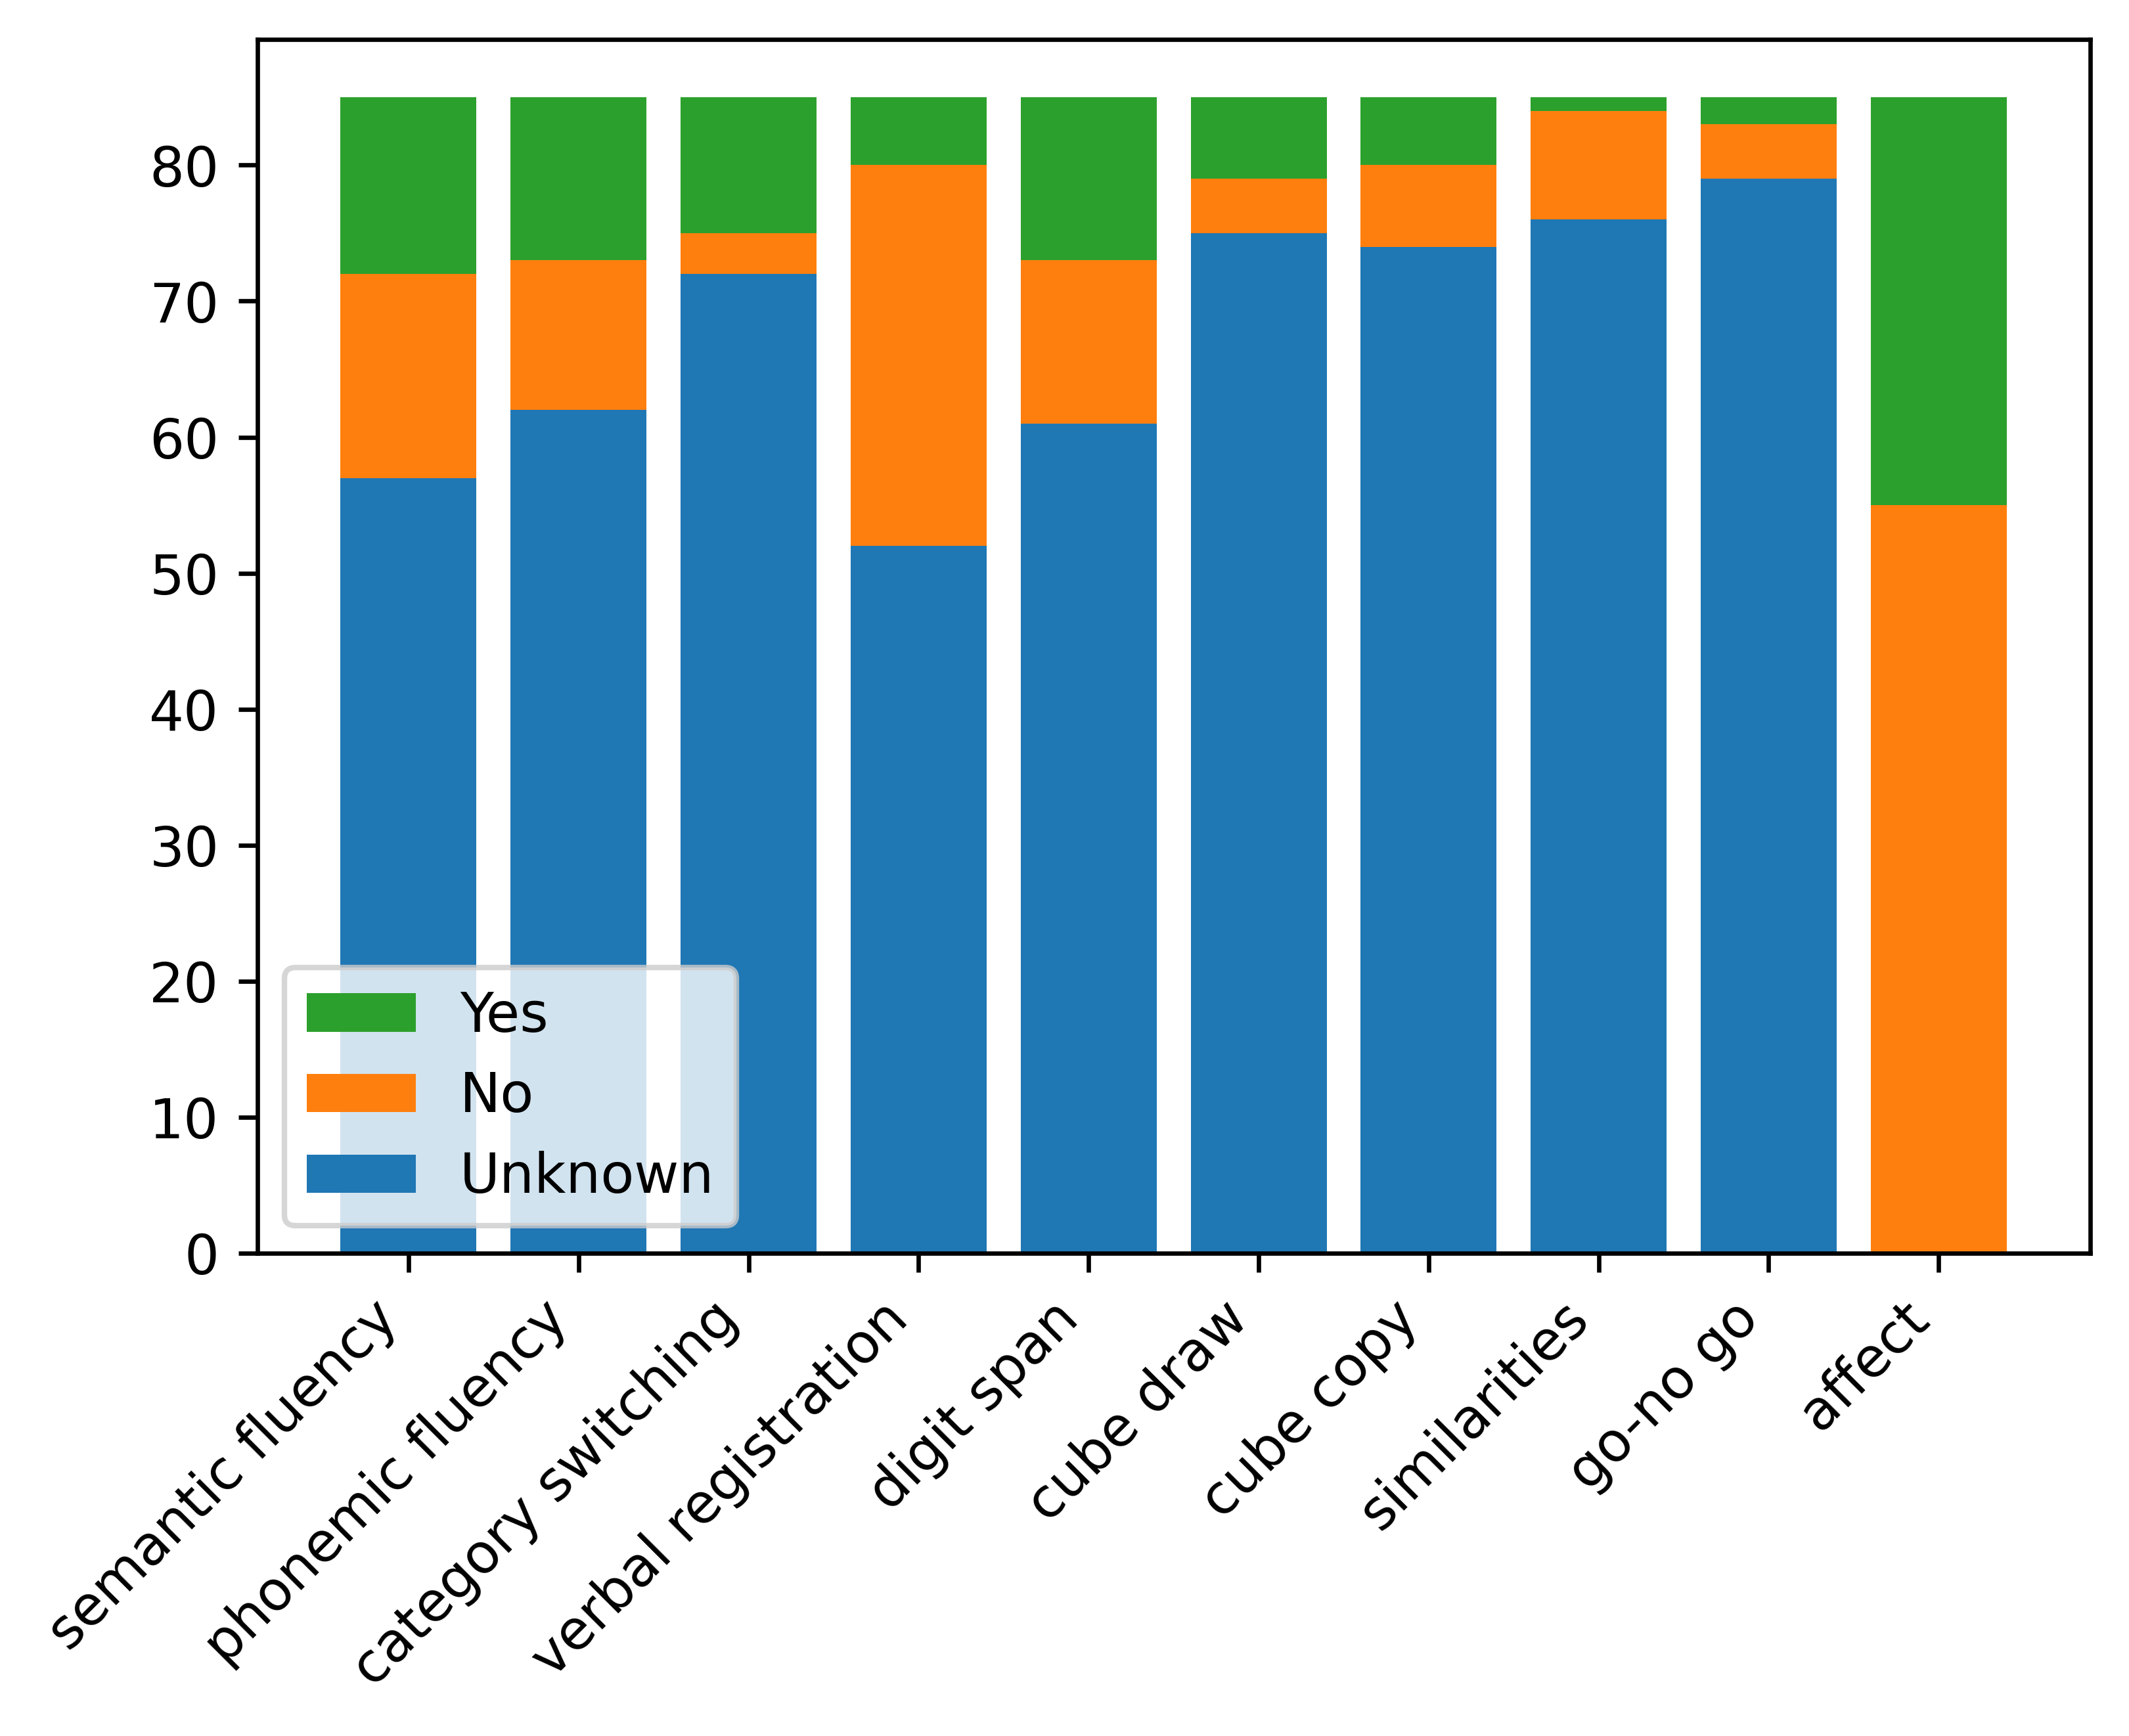

In [7]:
fig, ax = plt.subplots(figsize=(6,4), dpi=600)
bottom = np.zeros(10)
name_dict={ 0:'Unknown', 1:'No', 2:'Yes'}
for i, array in newcounts.items():
    ax.bar(gt.columns[1:-1], array, label=name_dict[i], bottom=bottom)
    bottom += array
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],)
# plt.legend()
plt.xticks(rotation=45, ha='right')
plt.savefig("/Users/rm026/Documents/schmahmann/ground_truth_ccas_distribution.png", bbox_inches='tight')
plt.show()

In [8]:
totals=counts.sum(axis=0)
props=totals/np.sum(totals)
props

0    0.715294
1    0.171765
2    0.112941
dtype: float64

In [104]:
sch_ccas=pd.read_csv('/Users/rm026/Partners HealthCare Dropbox/Ross Macfadyen/Schmahmann_SCA_atrophy/metadata/ccas.csv')
sch_ccas=sch_ccas[['Local_ID','Visit_Date']+[col for col in sch_ccas.columns if 'Fail' in col]]
sch_ccas.columns=['local_id', 'visit_date','semantic fluency exam','phonemic fluency exam','category switching exam','digit span forward exam','digit span backward exam','cube draw/copy exam','verbal registration exam','similarities exam','go no-go exam','affect exam', 'total fail score']
ccas_max=[]
for id in sch_ccas['local_id'].unique():
    subdf=sch_ccas[sch_ccas['local_id']==id]
    max_fails={}
    for col in subdf.columns[2:-1]:
        max_fails[col]=subdf[col].max()+1  # to convert from 0-indexed to 1-indexed
    ccas_max.append({'local_id':id, **max_fails})
ccas_max=pd.DataFrame(ccas_max)
ccas_max['digit span exam']=ccas_max[['digit span forward exam','digit span backward exam']].max(axis=1)
ccas_max

,local_id,semantic fluency exam,phonemic fluency exam,category switching exam,digit span forward exam,digit span backward exam,cube draw/copy exam,verbal registration exam,similarities exam,go no-go exam,affect exam,digit span exam
0,HA-01-002-7301,2,1,2,1,2,2,1,2,1,1,2
1,HA-01-005-7301,2,1,2,1,1,1,1,1,1,2,1
2,HA-01-009-7301,2,2,2,2,2,2,1,1,1,2,2
3,HA-01-010-7301,2,2,2,2,2,2,2,1,1,1,2
4,HA-01-015-7301,2,2,2,2,1,2,1,1,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
66,HA-01-106-7301,1,1,1,1,2,1,1,1,1,2,2
67,HA-01-107-7301,1,1,2,1,1,1,1,1,1,2,1
68,HA-01-108-7301,1,1,1,2,1,1,1,1,1,2,2
69,HA-01-109-7301,2,1,2,1,2,1,1,1,1,1,2


In [11]:
sub_df=pd.read_csv('/Users/rm026/Documents/Schmahmann/NAF Subject list with visit dates.csv')[['MRN ','Local ID']]
sub_df.rename({'MRN ':'MRN', 'Local ID':'local_id'}, axis=1, inplace=True)

missing=[]
key=[]
for i, row in sub_df.iterrows():
    mrn = row['MRN']
    if type(mrn) == float and np.isnan(mrn):
        continue
    code_index = codes.where(codes==mrn).dropna(how='all').dropna(axis=1).index
    if len(code_index)==0:
        print('still no sign of ', mrn)
        missing.append(mrn)
        continue
    key.append([codes['IncomingId'][code_index[0]],mrn, row['local_id']])
mrn_key=pd.DataFrame(key, columns=['rpdr_MRN','schmahmann_MRN','local_id'])
mrn_key.to_csv('/Users/rm026/Documents/schmahmann/mrn-local_id_key.csv', index=False)

still no sign of  5347756.0
still no sign of  4551420.0
still no sign of  2071224.0
